# 02_data_understanding
Ce notebook analyse automatiquement tous les CSV du dossier `data_pfe`, produit un rapport de qualité des données, détecte les clés candidates et les relations entre tables, et génère un dictionnaire de données exporté en Excel.

Il suit les étapes suivantes :
1. Importer les bibliothèques
2. Charger tous les CSV du dossier
3. Explorer les métadonnées et la structure des tables
4. Produire un rapport de qualité des données
5. Détecter les clés candidates et les relations entre tables
6. Générer un dictionnaire de données et exporter vers Excel

## 1. Importer les bibliothèques
Importer les modules nécessaires à l’analyse des CSV et à l’export Excel.

In [10]:
import pandas as pd
import re
from pathlib import Path

import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import openpyxl
except ImportError as exc:
    raise ImportError(
        "Le package openpyxl est requis pour l'export Excel. Installez-le avec `pip install openpyxl`."
    ) from exc

print('Chemin data_pfe:', Path('data_pfe').resolve())

csv_files = sorted(Path('data_pfe').glob('*.csv'))
print('CSV trouvés:', len(csv_files))
for csv_file in csv_files:
    print(' -', csv_file.name)


def read_csv_safely(path: Path) -> pd.DataFrame:
    """Load CSV with encoding fallback, without full-table string stripping (too slow on large files)."""
    for encoding in ['utf-8-sig', 'utf-8', 'cp1252']:
        try:
            # Read with skip whitespace to avoid BOM issues; don't use applymap (too slow)
            df = pd.read_csv(path, encoding=encoding, dtype=str, low_memory=False, skipinitialspace=True)
            # Replace empty strings with NA without applymap
            df = df.replace({'': pd.NA})
            return df
        except Exception:
            continue
    raise ValueError(f"Impossible de lire {path} avec les encodages standards.")


tables = {}
read_errors = []
for path in csv_files:
    try:
        tables[path.name] = read_csv_safely(path)
    except Exception as exc:
        read_errors.append({'file': path.name, 'error': str(exc)})

print('Tables chargées :', len(tables))
if read_errors:
    print('Erreurs de lecture :')
    for err in read_errors:
        print(err)

Chemin data_pfe: C:\Users\Mahmoud\Desktop\satge_pfe\data_pfe
CSV trouvés: 31
 - Devis_achat_ent_v.csv
 - Devis_achat_mouv_v.csv
 - Devis_vente_ent_v.csv
 - Devis_vente_ent_vv.csv
 - Devis_vente_mouv_v.csv
 - Devis_vente_mouv_vv.csv
 - Facture_achat_ent_v.csv
 - Facture_achat_mouv_v.csv
 - Facture_vente_ent_v.csv
 - facture_vente_ent_vv.csv
 - Facture_vente_mouv_v.csv
 - Fournisseurs_v.csv
 - GSL_ACHAT_BL_ENTETE.csv
 - Gsl_achat_bl_ligne.csv
 - Gsl_achat_bl_ligne_detail.csv
 - Gsl_vente_bl_entete.csv
 - Gsl_vente_bl_ligne.csv
 - Gsl_vente_bl_ligne_detail.csv
 - Gsl_vente_fa_entete.csv
 - Gsl_vente_fa_ligne.csv
 - Gsl_vente_ligne_detail.csv
 - Mb_facture_vente_mouv_v.csv
 - Ms_Bl_facture_ent_actif.csv
 - Ms_comparatif_achat.csv
 - Ms_comparatif_achat_facture.csv
 - Ms_comparatif_vente_facturecsv.csv
 - Ol_GCF_Facture_achat_base.csv
 - Table_etat_devis_technique_v.csv
 - table_nature_paiement_vcsv.csv
 - Zz_facture_vente_ent.csv
 - ZZ_Facture_vente_mouv.csv
Tables chargées : 31


## 3. Explorer les métadonnées et la structure des tables
Examiner le schéma, les types de colonnes, les valeurs manquantes et les statistiques descriptives pour chaque table.

In [11]:
def infer_column_type(series: pd.Series) -> str:
    if series.isna().all():
        return "empty"
    sample = series.dropna().astype(str).head(100)
    if sample.empty:
        return "unknown"
    if pd.to_datetime(sample, errors='coerce', dayfirst=False).notna().all():
        return "date"
    numeric = pd.to_numeric(sample.str.replace(",", "", regex=False), errors='coerce')
    if numeric.notna().all():
        return "numeric"
    return "string"


def normalize_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")


def normalize_values(series: pd.Series) -> pd.Series:
    values = series.dropna().astype(str).str.strip()
    values = values[values != ""]
    return values


table_summaries = []
column_profiles = []
for table_name, df in tables.items():
    nrows, ncols = df.shape
    table_summaries.append({
        "table": table_name,
        "rows": nrows,
        "columns": ncols,
        "duplicate_rows": int(df.duplicated().sum()),
        "empty_rows": int((df.isna() | df.astype(str).apply(lambda s: s.str.strip() == "")).all(axis=1).sum()),
    })
    for col in df.columns:
        series = df[col]
        values = normalize_values(series)
        distinct = int(values.nunique(dropna=True))
        missing = int(len(series) - len(values))
        top = values.value_counts(dropna=True).head(5).to_dict()
        column_profiles.append({
            "table": table_name,
            "column": col,
            "normalized_name": normalize_name(col),
            "inferred_type": infer_column_type(series),
            "unique_values": distinct,
            "missing_values": missing,
            "missing_rate": missing / max(1, nrows),
            "top_values": top,
            "sample_values": values.head(5).tolist(),
        })

metadata_df = pd.DataFrame(table_summaries)
column_profiles_df = pd.DataFrame(column_profiles)
metadata_df

C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_43672\999426624.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  if pd.to_datetime(sample, errors='coerce', dayfirst=False).notna().all():
C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_43672\999426624.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  if pd.to_datetime(sample, errors='coerce', dayfirst=False).notna().all():
C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_43672\999426624.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  if pd.to_datetime(sample, errors='coerce', dayfirst=False).notna().all():
C:\Users\Mahmoud

,table,rows,columns,duplicate_rows,empty_rows
0,Devis_achat_ent_v.csv,6,132,0,0
1,Devis_achat_mouv_v.csv,23,123,0,0
2,Devis_vente_ent_v.csv,8,130,0,0
3,Devis_vente_ent_vv.csv,4621,140,0,0
4,Devis_vente_mouv_v.csv,26934,133,0,0
5,Devis_vente_mouv_vv.csv,26944,114,9,10
6,Facture_achat_ent_v.csv,1844,145,0,0
7,Facture_achat_mouv_v.csv,19375,135,124,125
8,Facture_vente_ent_v.csv,128848,158,0,0
9,facture_vente_ent_vv.csv,128848,156,0,0


## 4. Produire un rapport de qualité des données
Calculer taux de complétude, doublons, valeurs aberrantes, colonnes constantes et incohérences, puis assembler un rapport global.

In [12]:
quality_rows = []
for table_name, df in tables.items():
    nrows = len(df)
    total_cells = nrows * df.shape[1]
    missing_count = int(df.isna().sum().sum())
    missing_rate = float(missing_count) / max(1, total_cells)
    duplicate_rows = int(df.duplicated().sum())
    constant_columns = int((df.nunique(dropna=False) <= 1).sum())
    empty_columns = int((df.isna().all()).sum())
    suspected_date_columns = int(
        (column_profiles_df.loc[column_profiles_df['table'] == table_name, 'inferred_type'] == 'date').sum()
    )
    suspected_numeric_columns = int(
        (column_profiles_df.loc[column_profiles_df['table'] == table_name, 'inferred_type'] == 'numeric').sum()
    )
    quality_rows.append({
        'table': table_name,
        'rows': nrows,
        'columns': df.shape[1],
        'missing_count': missing_count,
        'missing_rate': missing_rate,
        'duplicate_rows': duplicate_rows,
        'constant_columns': constant_columns,
        'empty_columns': empty_columns,
        'suspected_date_columns': suspected_date_columns,
        'suspected_numeric_columns': suspected_numeric_columns,
    })

quality_df = pd.DataFrame(quality_rows)
quality_df

,table,rows,columns,missing_count,missing_rate,duplicate_rows,constant_columns,empty_columns,suspected_date_columns,suspected_numeric_columns
0,Devis_achat_ent_v.csv,6,132,290,0.366162,0,74,40,4,57
1,Devis_achat_mouv_v.csv,23,123,859,0.303641,0,68,33,3,63
2,Devis_vente_ent_v.csv,8,130,339,0.325962,0,90,39,2,57
3,Devis_vente_ent_vv.csv,4621,140,245428,0.379367,0,55,33,4,57
4,Devis_vente_mouv_v.csv,26934,133,1051772,0.293609,0,28,28,3,66
5,Devis_vente_mouv_vv.csv,26944,114,1052905,0.342785,9,28,28,2,56
6,Facture_achat_ent_v.csv,1844,145,92093,0.344427,0,70,35,7,67
7,Facture_achat_mouv_v.csv,19375,135,708630,0.270922,124,2,2,1,99
8,Facture_vente_ent_v.csv,128848,158,7310478,0.359096,0,55,29,7,71
9,facture_vente_ent_vv.csv,128848,156,7242213,0.360304,0,55,29,7,70


## 5. Détecter les clés candidates et les relations entre tables
Identifier les colonnes uniques, les clés primaires potentielles et les relations de jointure entre tables en comparant les valeurs et les structures.

In [13]:
import pandas as pd
import re
from pathlib import Path

# Fallback: load CSVs if `tables` is missing or empty
if 'tables' not in globals() or not isinstance(tables, dict) or not tables:
    csv_files = sorted(Path('data_pfe').glob('*.csv'))
    tables = {}
    def read_csv_safely(path: Path) -> pd.DataFrame:
        for encoding in ['utf-8-sig', 'utf-8', 'cp1252']:
            try:
                df = pd.read_csv(path, encoding=encoding, dtype=str, low_memory=False)
                df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
                df = df.replace({'': pd.NA})
                return df
            except Exception:
                continue
        raise ValueError(f"Impossible de lire {path} avec les encodages standards.")
    read_errors = []
    for path in csv_files:
        try:
            tables[path.name] = read_csv_safely(path)
        except Exception as exc:
            read_errors.append({'file': path.name, 'error': str(exc)})
    print('Fallback: tables chargées :', len(tables))
    if read_errors:
        print('Erreurs de lecture (fallback) :')
        for err in read_errors:
            print(err)

# Normalization helper (ensure exists)
def normalize_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")

def find_candidate_keys(df: pd.DataFrame, max_pair_cols: int = 40, max_rows_for_composite: int = 20000):
    nrows = len(df)
    keys = []

    # Fast single-column unique key check (avoid full string conversions when possible)
    for col in df.columns:
        non_null_count = int(df[col].notna().sum())
        unique_count = int(df[col].nunique(dropna=True))
        # require no missing values and uniqueness across non-null values equal to total rows
        if non_null_count == nrows and unique_count == nrows:
            keys.append((col,))

    # Composite key search is expensive; only run on reasonably small tables
    if nrows <= max_rows_for_composite and len(df.columns) <= max_pair_cols and len(keys) < 5:
        # pick candidate columns that have reasonably high cardinality
        candidate_cols = [
            col
            for col in df.columns
            if df[col].nunique(dropna=True) / max(1, nrows) >= 0.4
        ]
        for i in range(len(candidate_cols)):
            for j in range(i + 1, len(candidate_cols)):
                cols = [candidate_cols[i], candidate_cols[j]]
                # build combined tuple and check uniqueness
                combined = df[cols].astype(str).apply(lambda row: "||".join([(v or "") for v in row.values]), axis=1)
                combined = combined.replace({'': pd.NA}).dropna()
                if len(combined) == nrows and combined.nunique() == nrows:
                    keys.append(tuple(cols))

    return keys

# Build key candidates using the safer function
key_candidates = []
for table_name, df in tables.items():
    for key in find_candidate_keys(df):
        key_candidates.append({
            'table': table_name,
            'candidate_key': ' + '.join(key),
            'columns': key,
            'key_type': 'single' if len(key) == 1 else 'composite',
        })

key_candidates_df = pd.DataFrame(key_candidates)

# OPTIMIZED Relationships detection: sample rows first, then check relationships
print("Détection des relations (optimisée avec pré-échantillonnage des lignes)...")
relationship_rows = []
MAX_SAMPLE_ROWS = 5000  # Sample at most 5k rows per table
MAX_COLS_TO_CHECK = 20  # Max columns to check per table

# Pre-sample data from each table for fast relationship detection
table_samples = {}
for table_name, df in tables.items():
    n = min(len(df), MAX_SAMPLE_ROWS)
    if len(df) > MAX_SAMPLE_ROWS:
        sample_df = df.sample(n=n, random_state=0)
    else:
        sample_df = df
    table_samples[table_name] = sample_df
    print(f"  {table_name}: {len(sample_df)} lignes échantillonnées")

# Check relationships only on sampled data
for left_name, left_sample in table_samples.items():
    # Limit columns to check
    left_cols = list(left_sample.columns[:MAX_COLS_TO_CHECK])
    
    for right_name, right_sample in table_samples.items():
        if left_name == right_name:
            continue
        
        right_cols = list(right_sample.columns[:MAX_COLS_TO_CHECK])
        
        for left_col in left_cols:
            left_norm = normalize_name(left_col)
            # Extract unique values from sampled left column (fast operation on sample)
            left_vals = set(
                left_sample[left_col]
                .dropna()
                .astype(str)
                .str.strip()
                .unique()
                .tolist()
            )
            if not left_vals:
                continue
            
            for right_col in right_cols:
                right_norm = normalize_name(right_col)
                if not (left_norm == right_norm or left_norm in right_norm or right_norm in left_norm):
                    continue
                
                # Extract unique values from sampled right column
                right_vals = set(
                    right_sample[right_col]
                    .dropna()
                    .astype(str)
                    .str.strip()
                    .unique()
                    .tolist()
                )
                if not right_vals:
                    continue
                
                common = left_vals & right_vals
                if not common:
                    continue
                
                # Compute ratios based on sample
                left_ratio = len(common) / max(1, len(left_vals))
                right_ratio = len(common) / max(1, len(right_vals))
                
                # Only report strong relationships
                if left_ratio >= 0.8 or right_ratio >= 0.8:
                    relationship_rows.append({
                        'left_table': left_name,
                        'left_column': left_col,
                        'right_table': right_name,
                        'right_column': right_col,
                        'left_unique': int(tables[left_name][left_col].nunique(dropna=True)),
                        'right_unique': int(tables[right_name][right_col].nunique(dropna=True)),
                        'overlap_count': int(len(common)),
                        'left_overlap_ratio': float(left_ratio),
                        'right_overlap_ratio': float(right_ratio),
                    })

relationships_df = pd.DataFrame(relationship_rows)
print(f"Relations détectées : {len(relationships_df)}")
key_candidates_df

Détection des relations (optimisée avec pré-échantillonnage des lignes)...
  Devis_achat_ent_v.csv: 6 lignes échantillonnées
  Devis_achat_mouv_v.csv: 23 lignes échantillonnées
  Devis_vente_ent_v.csv: 8 lignes échantillonnées
  Devis_vente_ent_vv.csv: 4621 lignes échantillonnées
  Devis_vente_mouv_v.csv: 5000 lignes échantillonnées
  Devis_vente_mouv_vv.csv: 5000 lignes échantillonnées
  Facture_achat_ent_v.csv: 1844 lignes échantillonnées
  Facture_achat_mouv_v.csv: 5000 lignes échantillonnées
  Facture_vente_ent_v.csv: 5000 lignes échantillonnées
  facture_vente_ent_vv.csv: 5000 lignes échantillonnées
  Facture_vente_mouv_v.csv: 5000 lignes échantillonnées
  Fournisseurs_v.csv: 609 lignes échantillonnées
  GSL_ACHAT_BL_ENTETE.csv: 1906 lignes échantillonnées
  Gsl_achat_bl_ligne.csv: 1073 lignes échantillonnées
  Gsl_achat_bl_ligne_detail.csv: 940 lignes échantillonnées
  Gsl_vente_bl_entete.csv: 1871 lignes échantillonnées
  Gsl_vente_bl_ligne.csv: 5000 lignes échantillonnées
  Gsl

,table,candidate_key,columns,key_type
0,Devis_achat_ent_v.csv,ENT_ID,"(ENT_ID,)",single
1,Devis_achat_ent_v.csv,CLE_DEVIS_VENTE_ENT,"(CLE_DEVIS_VENTE_ENT,)",single
2,Devis_achat_mouv_v.csv,MOUV_ID,"(MOUV_ID,)",single
3,Devis_achat_mouv_v.csv,CLE_ARTICLE,"(CLE_ARTICLE,)",single
4,Devis_achat_mouv_v.csv,CLE_SOUS_REFERENCE,"(CLE_SOUS_REFERENCE,)",single
5,Devis_vente_ent_v.csv,ENT_ID,"(ENT_ID,)",single
6,Devis_vente_ent_vv.csv,ENT_ID,"(ENT_ID,)",single
7,Devis_vente_ent_vv.csv,CLE_DEVIS_VENTE_ENT,"(CLE_DEVIS_VENTE_ENT,)",single
8,Devis_vente_mouv_v.csv,MOUV_ID,"(MOUV_ID,)",single
9,Facture_achat_ent_v.csv,ENT_ID,"(ENT_ID,)",single


## 6. Générer le dictionnaire de données et exporter vers Excel
Construire un dictionnaire de données décrivant chaque table et colonne, puis exporter le rapport de qualité et le dictionnaire en fichier Excel.

In [14]:
relationship_map = {}
for _, row in relationships_df.iterrows():
    relationship_map.setdefault((row['left_table'], row['left_column']), []).append(
        f"{row['right_table']}.{row['right_column']} (overlap={row['overlap_count']})"
    )
    relationship_map.setdefault((row['right_table'], row['right_column']), []).append(
        f"{row['left_table']}.{row['left_column']} (overlap={row['overlap_count']})"
    )

key_columns = set()
if not key_candidates_df.empty:
    for columns in key_candidates_df['columns']:
        key_columns.update(columns)

data_dict_rows = []
for table_name, df in tables.items():
    nrows = len(df)
    for col in df.columns:
        profile = column_profiles_df.loc[
            (column_profiles_df['table'] == table_name) & (column_profiles_df['column'] == col)
        ].iloc[0].to_dict()
        related = relationship_map.get((table_name, col), [])
        candidate_key_names = []
        if not key_candidates_df.empty:
            candidate_key_names = [
                row['candidate_key']
                for _, row in key_candidates_df.iterrows()
                if col in row['columns']
            ]
        data_dict_rows.append({
            'table': table_name,
            'column': col,
            'normalized_name': profile['normalized_name'],
            'inferred_type': profile['inferred_type'],
            'missing_values': profile['missing_values'],
            'missing_rate': profile['missing_rate'],
            'distinct_values': profile['unique_values'],
            'top_values': profile['top_values'],
            'sample_values': profile['sample_values'],
            'candidate_key': col in key_columns,
            'candidate_key_names': candidate_key_names,
            'related_columns': related,
            'row_count': nrows,
        })

data_dictionary_df = pd.DataFrame(data_dict_rows)
output_path = Path('data_pfe_data_dictionary.xlsx')
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    metadata_df.to_excel(writer, sheet_name='table_summary', index=False)
    column_profiles_df.to_excel(writer, sheet_name='column_profiles', index=False)
    quality_df.to_excel(writer, sheet_name='quality_report', index=False)
    key_candidates_df.to_excel(writer, sheet_name='candidate_keys', index=False)
    relationships_df.to_excel(writer, sheet_name='relationships', index=False)
    data_dictionary_df.to_excel(writer, sheet_name='data_dictionary', index=False)

print(f"Export Excel terminé : {output_path.resolve()}")
data_dictionary_df.head(20)

Export Excel terminé : C:\Users\Mahmoud\Desktop\satge_pfe\data_pfe_data_dictionary.xlsx


,table,column,normalized_name,inferred_type,missing_values,missing_rate,distinct_values,top_values,sample_values,candidate_key,candidate_key_names,related_columns,row_count
0,Devis_achat_ent_v.csv,ENT_ID,ent_id,numeric,0,0.000000,6,"{'538': 1, '6780': 1, '170474': 1, '172862': 1...","[538, 6780, 170474, 172862, 290644]",True,"[ENT_ID, ENT_ID, ENT_ID, ENT_ID, ENT_ID, ENT_I...",[],6
1,Devis_achat_ent_v.csv,CLE_DEVIS_VENTE_ENT,cle_devis_vente_ent,string,0,0.000000,6,"{'998 @F@ @10000001': 1, '995 ...","[998 @F@ @10000001, 995 @F@ ...",True,"[CLE_DEVIS_VENTE_ENT, CLE_DEVIS_VENTE_ENT, CLE...",[Facture_achat_ent_v.csv.CLE_DEVIS_VENTE_ENT (...,6
2,Devis_achat_ent_v.csv,CLE_DOSSIER,cle_dossier,numeric,0,0.000000,3,"{'1': 4, '998': 1, '995': 1}","[998, 995, 1, 1, 1]",False,[],[Devis_achat_mouv_v.csv.CLE_DOSSIER (overlap=3...,6
3,Devis_achat_ent_v.csv,CLE_ETABLISSEMENT,cle_etablissement,string,0,0.000000,3,"{'1 @01': 4, '998 @': 1, '995 @'...","[998 @, 995 @, 1 @01, 1 @0...",False,[],[Devis_achat_mouv_v.csv.CLE_ETABLISSEMENT (ove...,6
4,Devis_achat_ent_v.csv,CLE_FOURNISSEUR,cle_fournisseur,string,0,0.000000,4,"{'1 @FE000001': 3, '998 @F0000011': ...","[998 @F0000011, 995 @F0000011, 1 ...",True,[CLE_FOURNISSEUR],[Devis_achat_mouv_v.csv.CLE_FOURNISSEUR (overl...,6
5,Devis_achat_ent_v.csv,CLE_COMMERCIAL,cle_commercial,string,0,0.000000,3,"{'1 @': 4, '998 @': 1, '995 @': 1}","[998 @, 995 @, 1 @, 1 @, 1...",False,[],[Devis_achat_mouv_v.csv.CLE_COMMERCIAL (overla...,6
6,Devis_achat_ent_v.csv,CLE_COMMERCIAL_2,cle_commercial_2,string,0,0.000000,3,"{'1 @': 4, '998 @': 1, '995 @': 1}","[998 @, 995 @, 1 @, 1 @, 1...",False,[],[Devis_achat_mouv_v.csv.CLE_COMMERCIAL (overla...,6
7,Devis_achat_ent_v.csv,CLE_COMMERCIAL_3,cle_commercial_3,string,0,0.000000,3,"{'1 @': 4, '998 @': 1, '995 @': 1}","[998 @, 995 @, 1 @, 1 @, 1...",False,[],[Devis_achat_mouv_v.csv.CLE_COMMERCIAL (overla...,6
8,Devis_achat_ent_v.csv,CLE_CODE_OPERATION,cle_code_operation,string,0,0.000000,3,"{'1 @F': 4, '998 @F': 1, '995 @F...","[998 @F, 995 @F, 1 @F, 1 @...",False,[],[Devis_achat_mouv_v.csv.CLE_CODE_OPERATION (ov...,6
9,Devis_achat_ent_v.csv,CLE_CALENDRIER_PIECE,cle_calendrier_piece,date,0,0.000000,5,"{'20180803': 2, '20230228': 1, '20230307': 1, ...","[20180803, 20180803, 20230228, 20230307, 20250...",False,[],[Devis_vente_ent_vv.csv.CLE_CALENDRIER_PIECE (...,6


## 7. Visualisation des données et priorités de préparation
Tracer des graphiques clés pour comprendre la qualité des tables, identifier les points d'ancrage de la préparation et guider les actions de nettoyage.

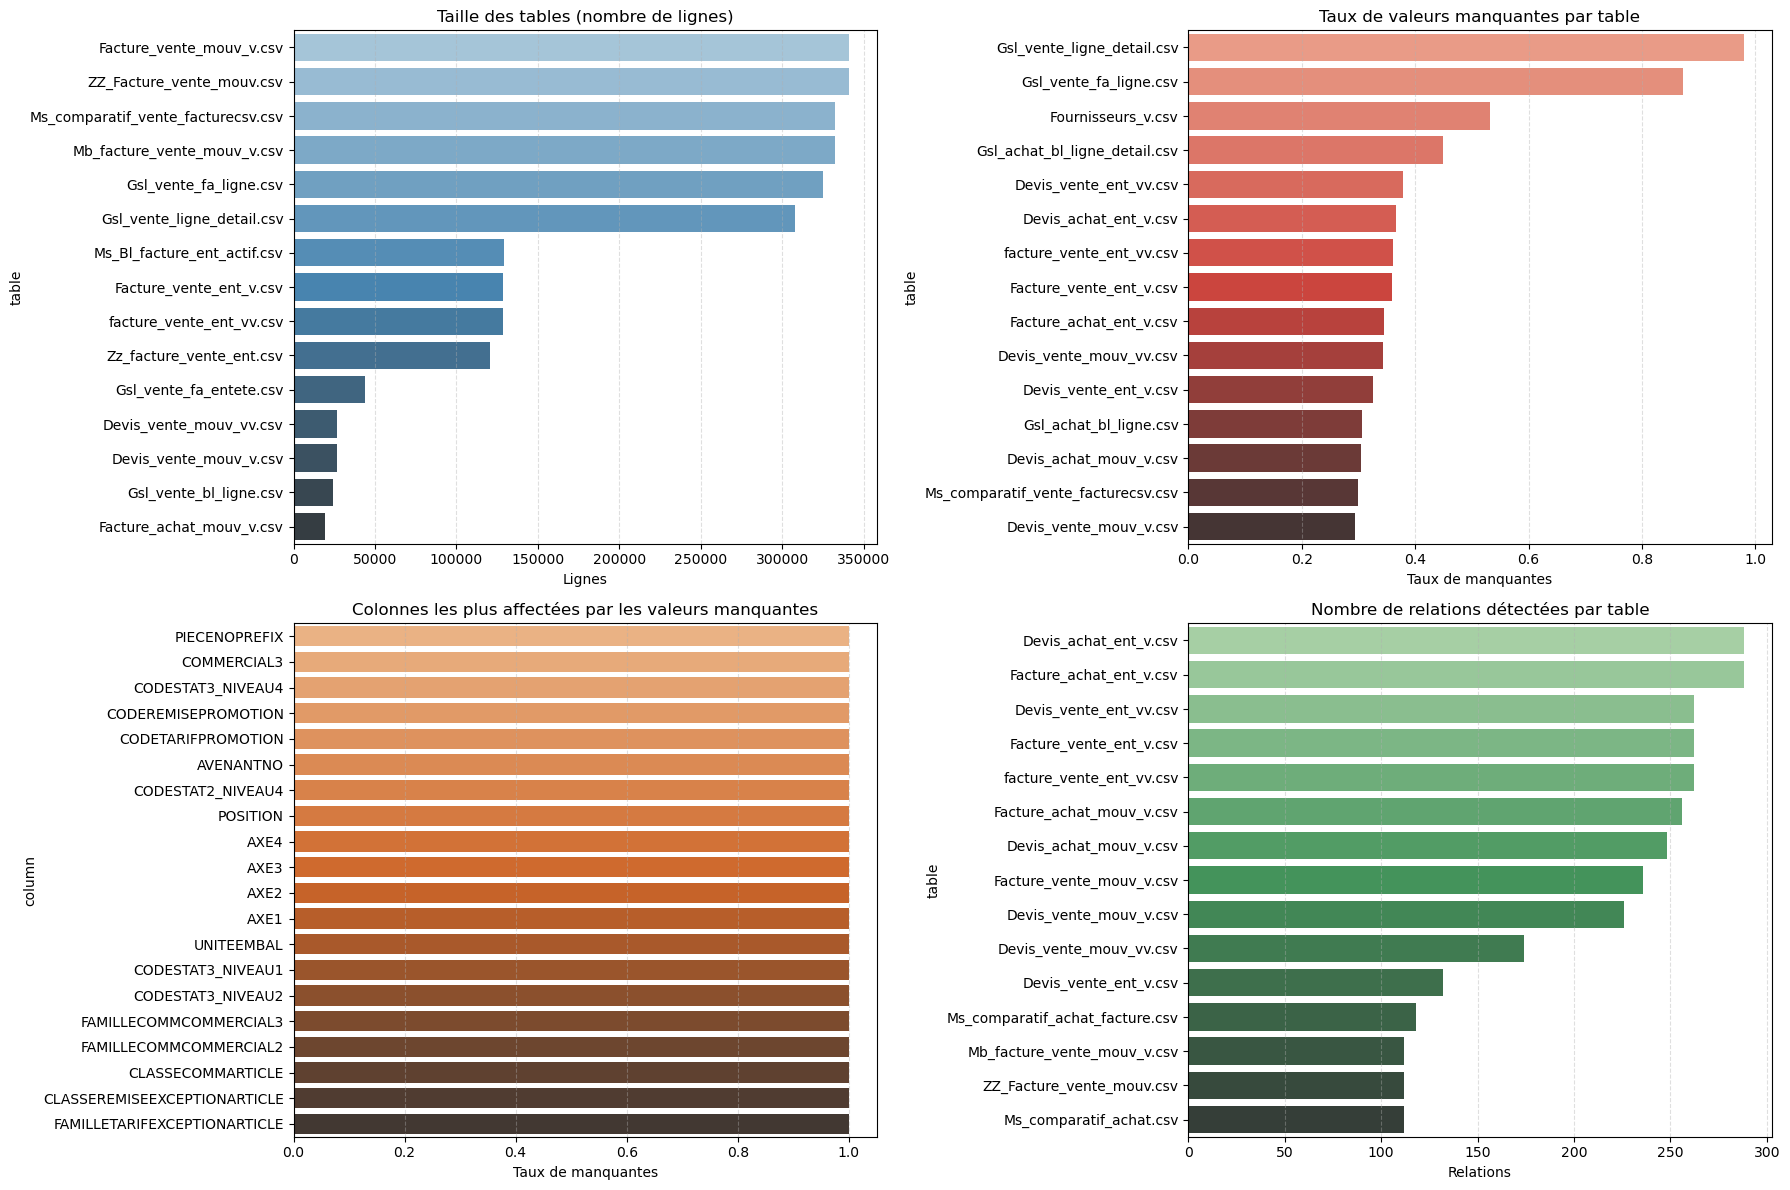

Tableaux de bord de préparation :
- Tables à fort volume de lignes indiquant l’impact du nettoyage.
- Tables avec de fortes valeurs manquantes à prioriser.
- Colonnes avec le taux de valeurs manquantes le plus élevé.
- Tables avec le plus grand nombre de relations potentielles.


In [15]:
# Visualisation des métriques clés et des priorités de préparation

table_chart = metadata_df.sort_values('rows', ascending=False).head(15)
missing_chart = quality_df.sort_values('missing_rate', ascending=False).head(15)

col_missing = (
    column_profiles_df
    .loc[column_profiles_df['missing_rate'] > 0]
    .sort_values('missing_rate', ascending=False)
    .head(20)
)

related_counts = (
    pd.concat([
        relationships_df[['left_table']].rename(columns={'left_table': 'table'}),
        relationships_df[['right_table']].rename(columns={'right_table': 'table'})
    ])
    .value_counts()
    .reset_index(name='relationship_count')
    .rename(columns={0: 'table'})
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

if sns is not None:
    sns.barplot(data=table_chart, x='rows', y='table', ax=axes[0, 0], palette='Blues_d')
    sns.barplot(data=missing_chart, x='missing_rate', y='table', ax=axes[0, 1], palette='Reds_d')
    sns.barplot(data=col_missing, x='missing_rate', y='column', ax=axes[1, 0], palette='Oranges_d')
    if not related_counts.empty:
        sns.barplot(data=related_counts.head(15), x='relationship_count', y='table', ax=axes[1, 1], palette='Greens_d')
else:
    axes[0, 0].barh(table_chart['table'], table_chart['rows'], color='tab:blue')
    axes[0, 1].barh(missing_chart['table'], missing_chart['missing_rate'], color='tab:red')
    axes[1, 0].barh(col_missing['column'], col_missing['missing_rate'], color='tab:orange')
    if not related_counts.empty:
        axes[1, 1].barh(related_counts.head(15)['table'], related_counts.head(15)['relationship_count'], color='tab:green')

axes[0, 0].set_title('Taille des tables (nombre de lignes)')
axes[0, 0].set_xlabel('Lignes')
axes[0, 1].set_title('Taux de valeurs manquantes par table')
axes[0, 1].set_xlabel('Taux de manquantes')
axes[1, 0].set_title('Colonnes les plus affectées par les valeurs manquantes')
axes[1, 0].set_xlabel('Taux de manquantes')
if not related_counts.empty:
    axes[1, 1].set_title('Nombre de relations détectées par table')
    axes[1, 1].set_xlabel('Relations')
else:
    axes[1, 1].set_title('Aucune relation détectée')

for ax in axes.flatten():
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print('Tableaux de bord de préparation :')
print('- Tables à fort volume de lignes indiquant l’impact du nettoyage.')
print('- Tables avec de fortes valeurs manquantes à prioriser.')
print('- Colonnes avec le taux de valeurs manquantes le plus élevé.')
print('- Tables avec le plus grand nombre de relations potentielles.')

---
### Résultats générés
- Fichier Excel : `data_pfe_data_dictionary.xlsx`
- Feuilles : `table_summary`, `column_profiles`, `quality_report`, `candidate_keys`, `relationships`, `data_dictionary`
- Ce notebook peut être relancé après ajout ou correction des fichiers CSV.